In [2]:
import matplotlib.pyplot as plt
import json
import numpy as np
import statistics

In [8]:
data1 = []
data1_path = f"E:/MTP/tokenskip/TokenSkip/outputs/Qwen2.5-3B-Instruct/math/3b/TokenSkip/clustered/train/optimal_predictions.jsonl"
with open(data1_path, "r") as f:
    for line in f:
        data1.append(json.loads(line))

print(data1[0])


{'dataset': 'math-clustered', 'id': 'math-clustered-test-0-0', 'level': 'Level 3', 'type': 'Intermediate Algebra', 'messages': [{'role': 'user', 'content': 'In a certain hyperbola, the center is at $(-2,0),$ one focus is at $(-2 + \\sqrt{34},0),$ and one vertex is at $(-5,0).$  The equation of this hyperbola can be written as\n\\[\\frac{(x - h)^2}{a^2} - \\frac{(y - k)^2}{b^2} = 1.\\]Find $h + k + a + b.$'}, {'role': 'assistant', 'content': ''}], 'answer': ['6'], 'reference': ['The center of the hyperbola is $(h,k) = (-2,0).$  The distance between the center and one vertex is $a = 3,$ and the distance between the center and one focus is $c = \\sqrt{34}.$  Then $b^2 = c^2 - a^2 = 34 - 3^2 = 25,$ so $b = 5.$\n\nTherefore, $h + k + a + b = -2 + 0 + 3 + 5 = \\boxed{6}.$'], 'prompt': '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nPlease reason step by step, and put your final answer within \\boxed{}.\nIn a certain hyperbola, the center is at $(-2,0),$ one foc

In [9]:
data2 = []
data2_path = f"E:/MTP/tokenskip/TokenSkip/outputs/Qwen2.5-3B-Instruct/math/3b/Original/train/samples/predictions_correct.jsonl"
with open(data2_path, "r") as f:
    for line in f:
        data2.append(json.loads(line))

print(data2[0])

{'dataset': 'math-test', 'id': 'math-test-test-0-0', 'level': 'Level 4', 'type': 'Algebra', 'messages': [{'role': 'user', 'content': 'Consider the polynomials  \\[f(x)=1-12x+3x^2-4x^3+5x^4\\] and \\[g(x)=3-2x-6x^3+9x^4.\\] Find $c$ such that the polynomial $f(x)+cg(x)$ has degree 3.'}, {'role': 'assistant', 'content': ''}], 'answer': ['-\\frac{5}{9}'], 'reference': ['The polynomial $f(x)+cg(x)$ will have degree 3 exactly when the $x^4$ terms cancel and the $x^3$ terms do not.  The $x^4$ term of $f(x)+cg(x)$ is \\[5x^4+c(9x^4)=(5+9c)x^4.\\]This is zero when $c=-5/9$.\n\nIf $c=-5/9$, the $x^3$ term is   \\[-4x^3+c(-6x^3)=(-4-6\\cdot -5/9)x^3=-\\frac{2}{3}x^3\\neq0.\\]Therefore there is only one solution $c=\\boxed{-\\frac{5}{9}}$.'], 'prompt': '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nPlease reason step by step, and put your final answer within \\boxed{}.\nConsider the polynomials  \\[f(x)=1-12x+3x^2-4x^3+5x^4\\] and \\[g(x)=3-2x-6x^3+9x^4.\\] Find $c

In [10]:
def load_questions(file_path):
    questions = set()
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                item = json.loads(line)
                # content of the first message (user role)
                question = item['messages'][0]['content'].strip()
                questions.add(question)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
    return questions

questions1 = load_questions(data1_path)
questions2 = load_questions(data2_path)

print(f"Total questions in data1: {len(questions1)}")
print(f"Total questions in data2: {len(questions2)}")

intersection = questions1.intersection(questions2)
print(f"Number of questions in data1 present in data2: {len(intersection)}")


Total questions in data1: 2000
Total questions in data2: 4969
Number of questions in data1 present in data2: 2000


In [11]:
output_path = r"e:/MTP/tokenskip/TokenSkip/outputs/Qwen2.5-3B-Instruct/math/3b/TokenSkip/intersecting_data2.jsonl"

In [12]:
def filter_and_save(source_path, target_questions, output_file):
    count_total = 0
    count_filtered = 0
    try:
        with open(source_path, 'r', encoding='utf-8') as f_in, \
             open(output_file, 'w', encoding='utf-8') as f_out:
            for line in f_in:
                count_total += 1
                item = json.loads(line)
                question = item['messages'][0]['content'].strip()
                
                if question in target_questions:
                    f_out.write(line)
                    count_filtered += 1
                    
        print(f"Processed {count_total} items from {source_path}")
        print(f"Saved {count_filtered} intersecting items to {output_file}")
        
    except Exception as e:
        print(f"Error processing files: {e}")

print("Loading questions from data1...")
questions1 = load_questions(data1_path)
print(f"Loaded {len(questions1)} unique questions from data1")

print("Filtering data2...")
filter_and_save(data2_path, questions1, output_path)

Loading questions from data1...
Loaded 2000 unique questions from data1
Filtering data2...
Processed 4969 items from E:/MTP/tokenskip/TokenSkip/outputs/Qwen2.5-3B-Instruct/math/3b/Original/train/samples/predictions_correct.jsonl
Saved 2000 intersecting items to e:/MTP/tokenskip/TokenSkip/outputs/Qwen2.5-3B-Instruct/math/3b/TokenSkip/intersecting_data2.jsonl


In [4]:
correct_optimal_only = []
average_optimal_only = 0

In [7]:
print(data1[0]['accuracy'])

True


In [8]:
for i, (d1,d2) in enumerate(zip(data1,data2)):
    if d1['accuracy'] == False and d2['accuracy'] == True:
        correct_optimal_only.append(d2)
        
print(len(correct_optimal_only))

10


In [9]:
correct_math_only = []
for i, (d1,d2) in enumerate(zip(data1,data2)):
    if d1['accuracy'] == True and d2['accuracy'] == False:
        correct_math_only.append(d2)
        
print(len(correct_math_only))


126


In [10]:
print(correct_math_only[0])

{'dataset': 'math-test', 'id': 'math-test-test-7-0', 'level': 4, 'type': 'Precalculus', 'messages': [{'role': 'user', 'content': 'The set of points $(x,y,z)$ that satisfy\n\\[2x = 3y = -z\\]is a line.\n\nThe set of points $(x,y,z)$ that satisfy\n\\[6x = -y = -4z\\]is another line.\n\nFind the angle between these lines, in degrees.'}, {'role': 'assistant', 'content': ''}], 'answer': ['90'], 'reference': ['For the first line, let $t = 2x = 3y = -z.$  Then\n\\[\\begin{pmatrix} x \\\\ y \\\\ z \\end{pmatrix} = \\begin{pmatrix} t/2 \\\\ t/3 \\\\ -t \\end{pmatrix} = \\frac{t}{6} \\begin{pmatrix} 3 \\\\ 2 \\\\ -6 \\end{pmatrix}.\\]Thus, the direction vector of the first line is $\\begin{pmatrix} 3 \\\\ 2 \\\\ -6 \\end{pmatrix}.$\n\nFor the second line, let $t = 6x = -y = -4z.$  Then\n\\[\\begin{pmatrix} x \\\\ y \\\\ z \\end{pmatrix} = \\begin{pmatrix} t/6 \\\\ -t \\\\ -t/4 \\end{pmatrix} = \\frac{t}{12} \\begin{pmatrix} 2 \\\\ -12 \\\\ -3 \\end{pmatrix}.\\]Thus, the direction vector of the f

In [11]:
incorrect_both = []
for i, (d1,d2) in enumerate(zip(data1,data2)):
    if d1['accuracy'] == False and d2['accuracy'] == False:
        incorrect_both.append(d2)
        
print(len(incorrect_both))


106


In [13]:
correct_both = []
compression_value = []
for i, (d1,d2) in enumerate(zip(data1,data2)):
    if d1['accuracy'] == True and d2['accuracy'] == True:
        compression_ratio = d2['cot_length'] / d1['cot_length']
        compression_value.append(compression_ratio)
        correct_both.append(d2)
        
print(len(correct_both))


258


In [18]:
avg = sum(compression_value) / len(compression_value)
max_val = np.max(compression_value)
std = statistics.stdev(compression_value)     # sample standard deviation
std_pop = statistics.pstdev(compression_value)  # population standard deviation

print("Sample STD:", std)
print("Population STD:", std_pop)
print("Average : ", avg)
print("Max tokens :", max_val)

Sample STD: 0.3316042289504047
Population STD: 0.33096096116918916
Average :  1.1384023030636257
Max tokens : 2.4213836477987423


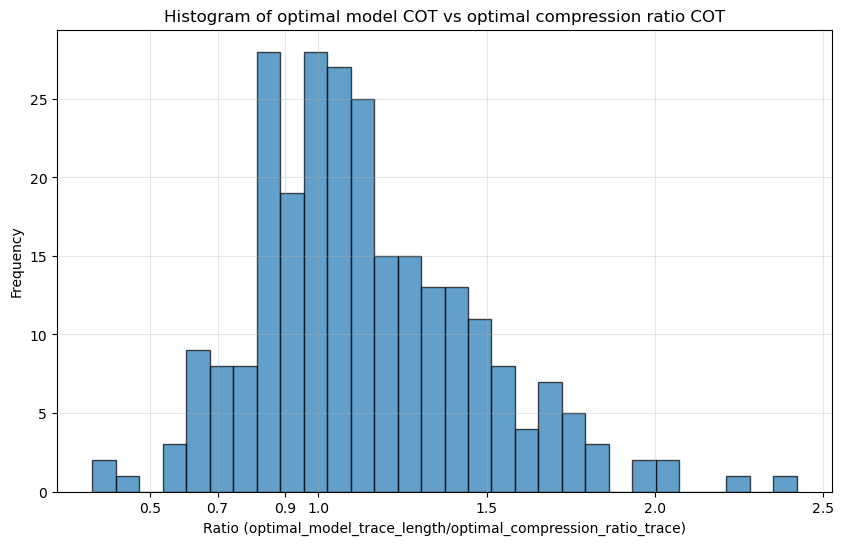

In [23]:
import matplotlib.pyplot as plt

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(compression_value, bins=30, edgecolor='black', alpha=0.7)
xticks = [0.5,0.7,0.9,1.0,1.5,2.0,2.5]
plt.xticks(xticks)
#plt.xlim(0,2.0)
plt.xlabel('Ratio (optimal_model_trace_length/optimal_compression_ratio_trace)')
plt.ylabel('Frequency')
plt.title(f'Histogram of optimal model COT vs optimal compression ratio COT')
plt.grid(True, alpha=0.3)
plt.show()